In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\oxcy\Desktop\EMTEQ PROEKT\NASHITE PODATOCI\IrinaP\IrinaP_eating_processed.csv")


In [4]:
df

,Software Timestamp,Hardware Timestamp,Accelerometer X,Accelerometer Y,Accelerometer Z,Gyroscope X,Gyroscope Y,Gyroscope Z,Magnetometer X,Magnetometer Y,...,Rotation Vector Z,Rotation Vector W,Navigation Right Temple X,Navigation Right Temple Y,Proximity Right Temple,Pressure,Navigation Right Temple IQ,Navigation Right Temple Shutter,Navigation Right Temple Frame Avg,Annotations
0,1765804980007,7385323151,-0.610730,-8.648416,4.109854,16.280487,-28.109756,11.219512,-11.1875,40.0625,...,-4914,13095,0.0,0.0,22.333902,100553.125,203,40,12,0
1,1765804980027,7385343151,-0.622705,-8.811276,4.308640,20.121952,-27.804878,11.524390,-10.9375,40.1875,...,-4863,13149,-1.0,-1.0,22.354277,100553.125,208,40,12,0
2,1765804980040,7385363151,-0.658630,-9.093889,4.454736,22.439024,-28.902440,13.292683,-10.7500,40.1875,...,-4813,13206,-1.0,0.0,22.374700,100553.125,208,40,12,0
3,1765804980061,7385383151,-0.687371,-8.873548,4.799619,22.439024,-30.304878,16.707317,-10.5000,40.1875,...,-4749,13270,0.0,-2.0,22.354277,100553.125,207,40,12,0
4,1765804980085,7385403151,-0.785566,-8.892708,4.770879,20.426828,-30.426828,16.646341,-10.4375,40.2500,...,-4687,13328,-3.0,0.0,22.333902,100553.125,209,40,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26991,1765805519907,7925263151,0.313748,-9.541758,2.086062,-1.158537,0.243902,-1.097561,-20.3125,36.8750,...,-8466,9679,9.0,0.0,35.837112,100589.840,197,168,12,1
26992,1765805519930,7925283151,0.198787,-9.687854,2.203418,-0.548781,0.670732,-0.853659,-20.4375,36.8750,...,-8467,9676,35.0,1.0,35.768448,100589.840,191,104,12,1
26993,1765805519952,7925303151,0.651445,-9.510623,2.802173,-7.134146,4.451220,2.256098,-20.2500,36.8125,...,-8466,9670,5.0,9.0,35.497055,100589.060,196,232,12,1
26994,1765805519974,7925323151,0.215552,-8.883127,0.910107,4.024390,-0.182927,-3.109756,-20.1875,36.8125,...,-8459,9663,19.0,6.0,35.430008,100589.060,196,168,12,1


In [5]:
features = [
    "Accelerometer X", "Accelerometer Y", "Accelerometer Z",
    "Gyroscope X", "Gyroscope Y", "Gyroscope Z",
    "Magnetometer X", "Magnetometer Y", "Magnetometer Z",
    "Rotation Vector X", "Rotation Vector Y", "Rotation Vector Z", "Rotation Vector W",
    "Navigation Right Temple X", "Navigation Right Temple Y",
    "Proximity Right Temple", "Pressure",
    "Navigation Right Temple IQ",
    "Navigation Right Temple Shutter",
    "Navigation Right Temple Frame Avg",
    "Hardware Timestamp", "Software Timestamp"
]


In [6]:
cols_to_drop = [
    "Accelerometer Z",
    "Gyroscope Z",
    "Rotation Vector Z",
    "Rotation Vector W",
    "Magnetometer X",
    "Magnetometer Y",
    "Magnetometer Z"    
]

In [7]:
target_col = "Annotations"

In [9]:
X = df.drop(columns=cols_to_drop + [target_col])
y = df[target_col]


In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Target distribution:")
print(y.value_counts())


X shape: (26996, 15)
y shape: (26996,)
Target distribution:
Annotations
1    14526
0    12470
Name: count, dtype: int64


In [11]:
df.describe()

,Software Timestamp,Hardware Timestamp,Accelerometer X,Accelerometer Y,Accelerometer Z,Gyroscope X,Gyroscope Y,Gyroscope Z,Magnetometer X,Magnetometer Y,...,Rotation Vector Z,Rotation Vector W,Navigation Right Temple X,Navigation Right Temple Y,Proximity Right Temple,Pressure,Navigation Right Temple IQ,Navigation Right Temple Shutter,Navigation Right Temple Frame Avg,Annotations
count,2.699600e+04,2.699600e+04,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,...,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000,26996.000000
mean,1.765805e+12,7.655358e+09,0.355831,-8.872166,3.830839,0.128795,-0.022454,-0.020981,-20.354735,33.583167,...,-9624.097459,9705.380945,0.005927,-0.081197,28.636673,100575.491810,202.602682,132.650170,12.270225,0.538080
std,1.558954e+05,1.559059e+08,0.397441,0.539247,1.526529,9.071721,8.198035,4.438713,1.533863,2.270171,...,876.608926,655.348815,6.989350,6.982915,4.255640,10.208419,6.531166,72.315281,0.899007,0.498557
min,1.765805e+12,7.385323e+09,-1.851350,-11.021880,-1.619033,-128.414630,-82.987810,-87.256096,-27.062500,22.125000,...,-11789.000000,7431.000000,-78.000000,-123.000000,19.844690,100549.220000,2.000000,8.000000,12.000000,0.000000
25%,1.765805e+12,7.520318e+09,0.122146,-9.256750,3.187771,-2.743902,-2.865854,-1.341463,-21.187500,32.312500,...,-10168.000000,9303.750000,-1.000000,-1.000000,24.648386,100567.970000,199.000000,40.000000,12.000000,0.000000
50%,1.765805e+12,7.655393e+09,0.340093,-8.806487,4.306245,0.365854,-0.365854,0.121951,-20.375000,33.562500,...,-9811.000000,9799.000000,0.000000,0.000000,29.086674,100578.910000,203.000000,104.000000,12.000000,1.000000
75%,1.765805e+12,7.790368e+09,0.577200,-8.514295,4.855303,3.475610,2.012195,1.585366,-19.562500,35.000000,...,-9286.000000,10149.000000,1.000000,1.000000,32.069140,100583.590000,206.000000,176.000000,12.000000,1.000000
max,1.765806e+12,7.925343e+09,4.157754,-6.670129,7.220984,94.878050,115.609760,42.256096,-7.062500,40.750000,...,-3866.000000,14012.000000,73.000000,227.000000,36.470276,100592.970000,216.000000,232.000000,57.000000,1.000000


In [13]:
from scipy.stats import skew, kurtosis

def zero_crossing_rate(x):
    x = x.dropna().values
    return np.mean(x[:-1] * x[1:] < 0) if len(x) > 1 else 0

smart_describe = pd.DataFrame({
    "mean": X.mean(),
    "std": X.std(),
    "cv": X.std() / (X.mean().abs() + 1e-6),   # coefficient of variation
    "min": X.min(),
    "max": X.max(),
    "skew": X.apply(skew),
    "kurtosis": X.apply(kurtosis),
    "rms": np.sqrt((X**2).mean()),
    "energy": (X**2).sum(),
    "zero_crossing_rate": X.apply(zero_crossing_rate)
})

smart_describe.sort_values("rms", ascending=False)


C:\Users\oxcy\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


,mean,std,cv,min,max,skew,kurtosis,rms,energy,zero_crossing_rate
Hardware Timestamp,7.655358e+09,1.559059e+08,2.036559e-02,7.385323e+09,7.925343e+09,-0.000357,-1.200052,1.813446e+09,-5.548795e+18,0.099611
Pressure,1.005755e+05,1.020842e+01,1.015001e-04,1.005492e+05,1.005930e+05,-0.700616,-0.560845,1.005755e+05,2.730761e+14,0.000000
Rotation Vector X,-6.402657e+03,1.004864e+03,1.569449e-01,-9.910000e+03,-4.424000e+03,-1.212564,1.110067,6.481029e+03,1.133933e+12,0.000000
Rotation Vector Y,6.150766e+03,7.432493e+02,1.208385e-01,3.073000e+03,8.969000e+03,0.364813,0.408922,6.195508e+03,1.036223e+12,0.000000
Navigation Right Temple IQ,2.026027e+02,6.531166e+00,3.223633e-02,2.000000e+00,2.160000e+02,-15.883602,437.723853,2.027079e+02,1.109279e+09,0.000000
Navigation Right Temple Shutter,1.326502e+02,7.231528e+01,5.451578e-01,8.000000e+00,2.320000e+02,0.008510,-1.321007,1.510807e+02,6.161938e+08,0.000000
Proximity Right Temple,2.863667e+01,4.255640e+00,1.486080e-01,1.984469e+01,3.647028e+01,-0.055511,-1.237699,2.895115e+01,2.262721e+07,0.000000
Navigation Right Temple Frame Avg,1.227023e+01,8.990066e-01,7.326732e-02,1.200000e+01,5.700000e+01,7.065868,231.812428,1.230311e+01,4.086293e+06,0.000000
Gyroscope X,1.287951e-01,9.071721e+00,7.043477e+01,-1.284146e+02,9.487805e+01,-0.920691,18.856502,9.072467e+00,2.222031e+06,0.091128
Accelerometer Y,-8.872166e+00,5.392468e-01,6.077961e-02,-1.102188e+01,-6.670129e+00,0.042198,0.341863,8.888537e+00,2.132849e+06,0.000000


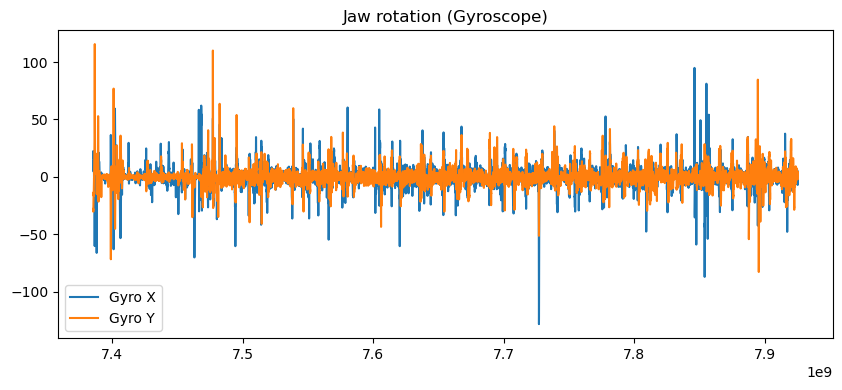

In [29]:
plt.figure(figsize=(10,4))
plt.plot(df["Hardware Timestamp"], df["Gyroscope X"], label="Gyro X")
plt.plot(df["Hardware Timestamp"], df["Gyroscope Y"], label="Gyro Y")
plt.legend()
plt.title("Jaw rotation (Gyroscope)")
plt.show()


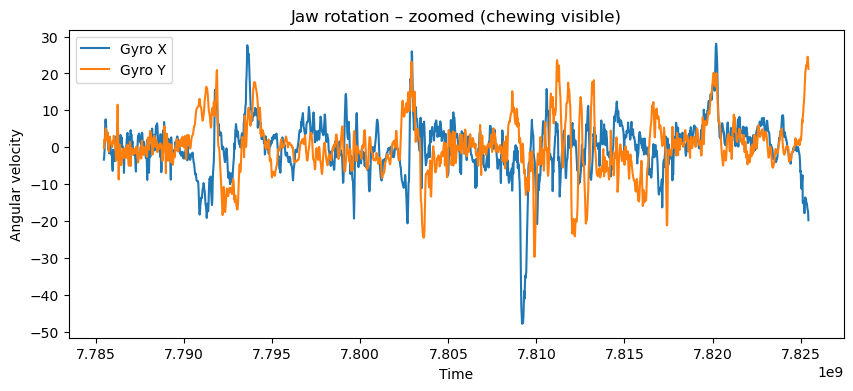

In [24]:
# пример: избери интервал
start_time = df["Hardware Timestamp"].iloc[20000]
end_time   = df["Hardware Timestamp"].iloc[22000]

zoom_df = df[
    (df["Hardware Timestamp"] >= start_time) &
    (df["Hardware Timestamp"] <= end_time)
]

plt.figure(figsize=(10,4))
plt.plot(zoom_df["Hardware Timestamp"], zoom_df["Gyroscope X"], label="Gyro X")
plt.plot(zoom_df["Hardware Timestamp"], zoom_df["Gyroscope Y"], label="Gyro Y")
plt.legend()
plt.title("Jaw rotation – zoomed (chewing visible)")
plt.xlabel("Time")
plt.ylabel("Angular velocity")
plt.show()


✅ 1️⃣ Периодични осцилации

Gyro X и Gyro Y осцилираат околу 0

Има повторувачки циклуси
👉 тоа е механиката на вилицата

✅ 2️⃣ X и Y се поврзани

кога X оди нагоре, Y реагира

мала фаза разлика → природно движење

⚠️ 3️⃣ Голем spike околу 7.81e9

Ова е НЕ chewing:

swallow

reposition на главата

artifact

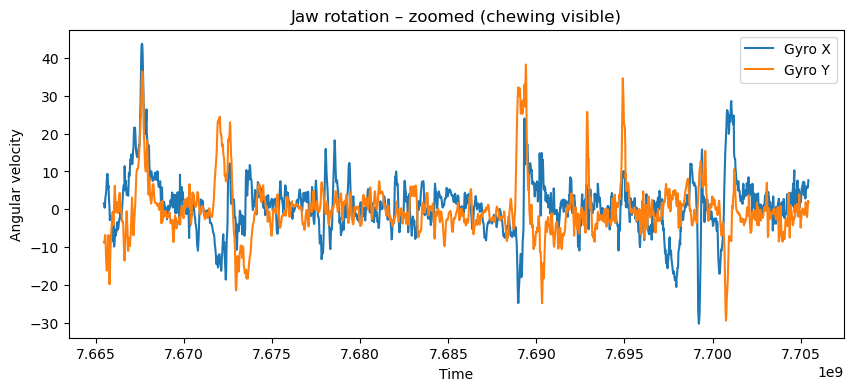

In [27]:
# пример: избери интервал
start_time = df["Hardware Timestamp"].iloc[14000]
end_time   = df["Hardware Timestamp"].iloc[16000]

zoom_df = df[
    (df["Hardware Timestamp"] >= start_time) &
    (df["Hardware Timestamp"] <= end_time)
]

plt.figure(figsize=(10,4))
plt.plot(zoom_df["Hardware Timestamp"], zoom_df["Gyroscope X"], label="Gyro X")
plt.plot(zoom_df["Hardware Timestamp"], zoom_df["Gyroscope Y"], label="Gyro Y")
plt.legend()
plt.title("Jaw rotation – zoomed (chewing visible)")
plt.xlabel("Time")
plt.ylabel("Angular velocity")
plt.show()

#### gledame 40 ms worth of dzvakanje

* jako dzvakanje, goltanje

In [30]:
df["Hardware Timestamp"].min(), df["Hardware Timestamp"].max()


(7385323151, 7925343152)

In [36]:
dt = df["Hardware Timestamp"].diff().dropna()

print("median dt:", dt.median())
print("mean dt:", dt.mean())
print("min dt:", dt.min(), "max dt:", dt.max())


median dt: 20000.0
mean dt: 20004.445304686054
min dt: 18755.0 max dt: 40011.0


In [34]:
t0 = df["Hardware Timestamp"].iloc[0]
time_sec = (df["Hardware Timestamp"] - t0) / 1e6


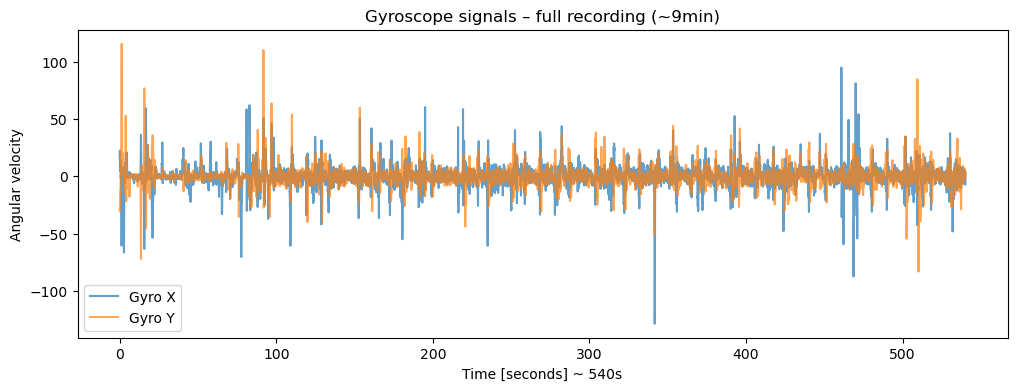

In [38]:
plt.figure(figsize=(12,4))
plt.plot(time_sec, df["Gyroscope X"], label="Gyro X", alpha=0.7)
plt.plot(time_sec, df["Gyroscope Y"], label="Gyro Y", alpha=0.7)
plt.xlabel("Time [seconds] ~ 540s")
plt.ylabel("Angular velocity")
plt.title("Gyroscope signals – full recording (~9min)")
plt.legend()
plt.show()


* Koga ima ritam mozhe da sogledame deka e dzvakanje
* Pikovite koi gi gledame okolu ~0s, ~80s, ~470s, se najverojatno zboruvanje, prilagoduvanje na naocarite, naglo dvizenje na glava

* Na pocetok gledame deka e povekje haos => postavuvanje, prvi zalci, ushte se plasi da e sniman :D
* Sredina => stabidel signal, ramnomeren pattern => normalno jadenje
* Kraj => povekje golemi dvizenja => pauzi, posledni zalci

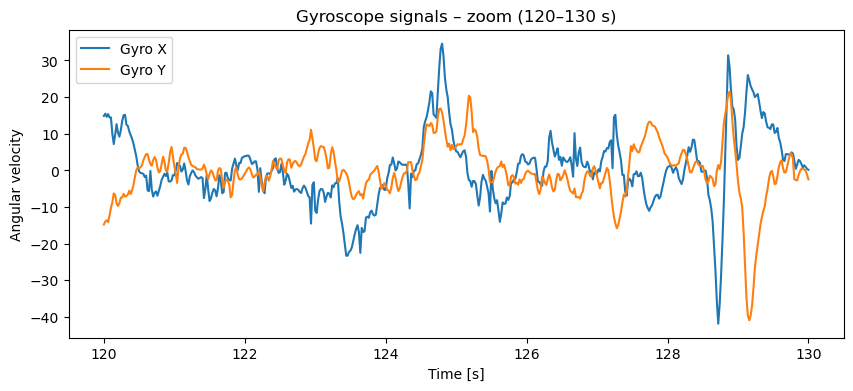

In [39]:
start_s = 120      # од 2-та минута
end_s   = 130      # до 2:10

zoom_df = df[(time_sec >= start_s) & (time_sec <= end_s)]

plt.figure(figsize=(10,4))
plt.plot(time_sec[zoom_df.index], zoom_df["Gyroscope X"], label="Gyro X")
plt.plot(time_sec[zoom_df.index], zoom_df["Gyroscope Y"], label="Gyro Y")
plt.xlabel("Time [s]")
plt.ylabel("Angular velocity")
plt.title("Gyroscope signals – zoom (120–130 s)")
plt.legend()
plt.show()


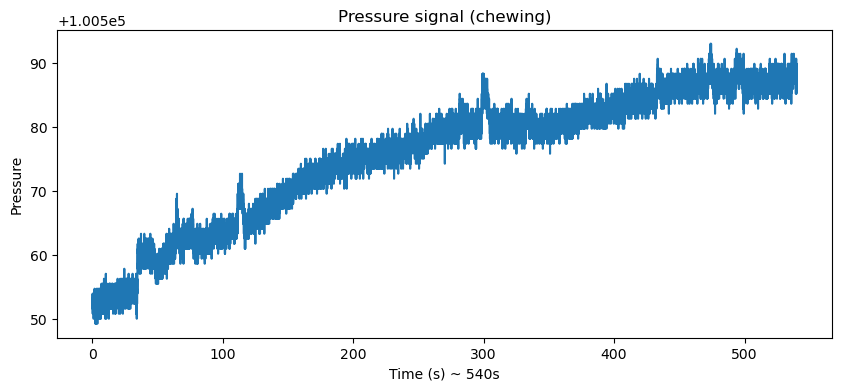

In [41]:

plt.figure(figsize=(10,4))
plt.plot(time_sec, df["Pressure"], label = "Pressure" )
plt.title("Pressure signal (chewing)")
plt.xlabel("Time (s) ~ 540s")
plt.ylabel("Pressure")
plt.show()


Senzorot pocnuva laden, i so tek na vreme se zagreva. Bidejki pressure senzorite se ekstremno  custvitelni na temperatura, toa sozdava baven, monoton rast 

„Dolgorochniot rast vo pressure signalot e rezultat na termalen i mehanichki drift na senzorot, dodeka chewing aktivnosta e prisutna kako brzi fluktuacii vrz ovoj trend.“

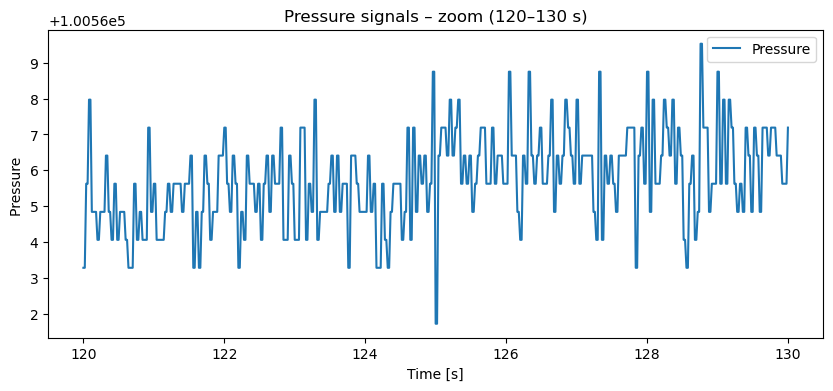

In [42]:
start_s = 120      # од 2-та минута
end_s   = 130      # до 2:10

zoom_df = df[(time_sec >= start_s) & (time_sec <= end_s)]

plt.figure(figsize=(10,4))
plt.plot(time_sec[zoom_df.index], zoom_df["Pressure"], label="Pressure")
plt.xlabel("Time [s]")
plt.ylabel("Pressure ")
plt.title("Pressure signals – zoom (120–130 s)")
plt.legend()
plt.show()


Vo zumirani vremenski intervali (120–130 s), pressure signalot pokazuva brzi fluktuacii so mala amplituda, koi korespondiraat so kontrakcijata na dzvakachkite muskuli za vreme na dzvakanje. Povremenite izolirani padovi se rezultat na goltanje ili kratki mehanichki artefakti.


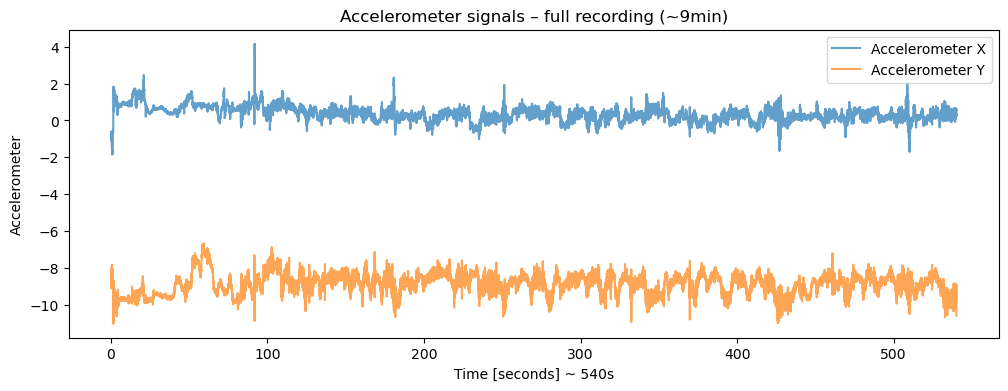

In [45]:
plt.figure(figsize=(12,4))
plt.plot(time_sec, df["Accelerometer X"], label="Accelerometer X", alpha=0.7)
plt.plot(time_sec, df["Accelerometer Y"], label="Accelerometer Y", alpha=0.7)
plt.xlabel("Time [seconds] ~ 540s")
plt.ylabel("Accelerometer")
plt.title("Accelerometer signals – full recording (~9min)")
plt.legend()
plt.show()


Accelerometer signalite pokazuvaat relativno stabilni vrednosti vo tekot na snimanjeto, pri shto Y-oskata e dominirana od gravitacijata, a X-oskata ima samo mali fluktuacii. Ova ukazhuva deka linearnite dvizhenja na glavata se minimalni i deka dzvakanjeto ne predizvikuva znachajna linearna akceleracija.

KADE MOZHE DA SE KORISTI ACCELEROMETER

* detekcija na dvizhenje / odenje
* detekcija na golemi artefakti
* normalizacija na orientacija

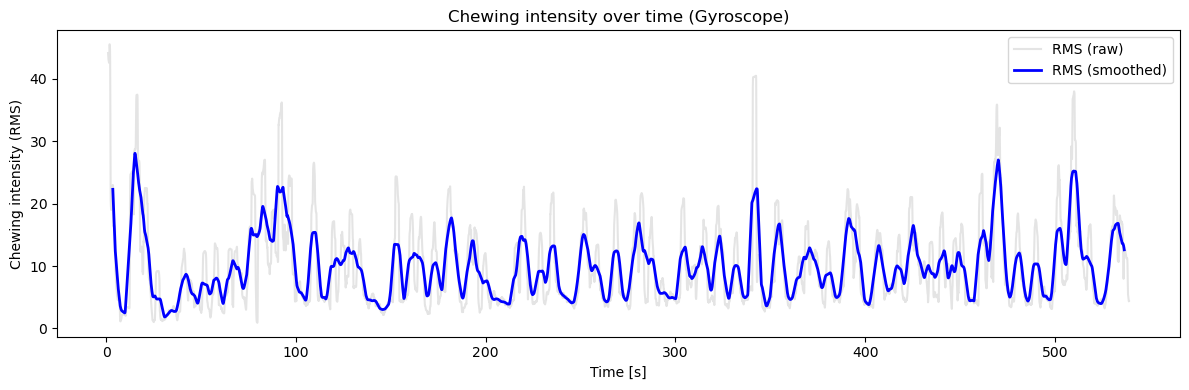

In [49]:
fs = 50  # кај тебе ~50Hz
# дополнително мазнење (пример: 5 секунди)
smooth_win_s = 5
smooth_win = int(smooth_win_s * fs)

rms_smooth = rms.rolling(smooth_win, center=True).mean()
plt.figure(figsize=(12,4))

plt.plot(time_sec, rms, 
         color="lightgray", alpha=0.6, label="RMS (raw)")
plt.plot(time_sec, rms_smooth, 
         color="blue", linewidth=2, label="RMS (smoothed)")

plt.xlabel("Time [s]")
plt.ylabel("Chewing intensity (RMS)")
plt.title("Chewing intensity over time (Gyroscope)")
plt.legend()
plt.tight_layout()
plt.show()


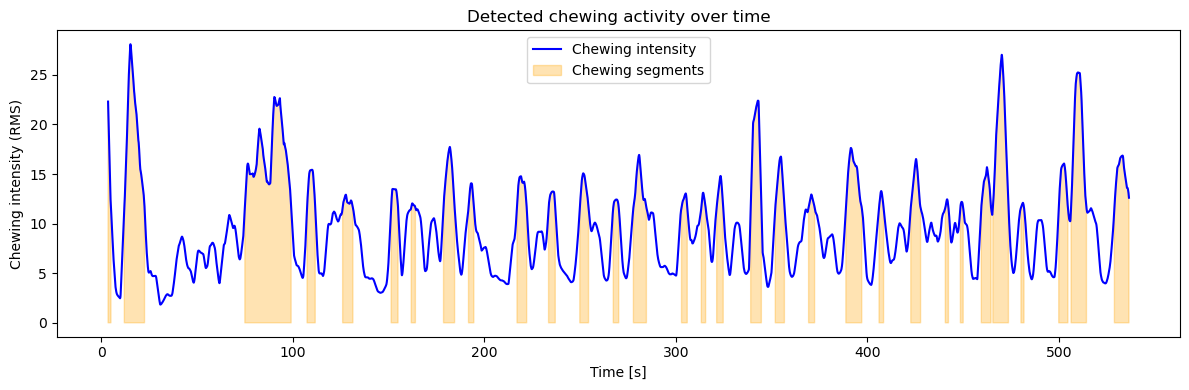

In [51]:
thr = rms_smooth.quantile(0.7)   # праг (70-ти перцентил)
chewing = rms_smooth > thr

plt.figure(figsize=(12,4))
plt.plot(time_sec, rms_smooth, color="blue", label="Chewing intensity")

plt.fill_between(time_sec, 0, rms_smooth,
                 where=chewing,
                 color="orange", alpha=0.3,
                 label="Chewing segments")

plt.xlabel("Time [s]")
plt.ylabel("Chewing intensity (RMS)")
plt.title("Detected chewing activity over time")
plt.legend()
plt.tight_layout()
plt.show()


Grafikot ja prikazhuva detektiranata aktivnost na dzvakanje kako funkcija od vremeto, pri shto RMS intenzitetot na gyroscope signalite sluzhi kako indikator za jachinata na muskularnata aktivnost. Periodite vo koi intenzitetot ja nadminuva prag-vrednosta se oznacheni kako aktivni segmenti na dzvakanje, dodeka poniskite vrednosti soodvetstvuvaat na pauzi ili neaktivni intervali.

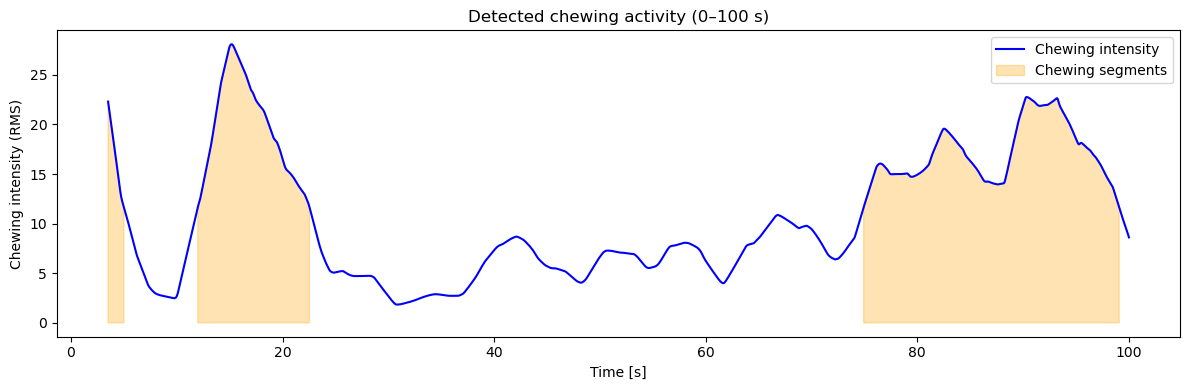

In [52]:
# ZOOM: 0–100 seconds
mask = (time_sec >= 0) & (time_sec <= 100)

plt.figure(figsize=(12,4))

plt.plot(time_sec[mask], rms_smooth[mask],
         color="blue", label="Chewing intensity")

plt.fill_between(time_sec[mask], 0, rms_smooth[mask],
                 where=chewing[mask],
                 color="orange", alpha=0.3,
                 label="Chewing segments")

plt.xlabel("Time [s]")
plt.ylabel("Chewing intensity (RMS)")
plt.title("Detected chewing activity (0–100 s)")
plt.legend()
plt.tight_layout()
plt.show()


In [55]:
thr = rms_smooth.quantile(0.7)
thr

11.596130236495114

Vremenskite segmenti vo koi RMS intenzitetot ja nadminuva vrednosta na 70-tiот percentil(odnosno vrednosta e pogolema od 70% od vrednostite odnosno nad 11.596..) se interpretiraat kako periodi na pointenzivno dzvakanje i se vizuelno oznacheni.

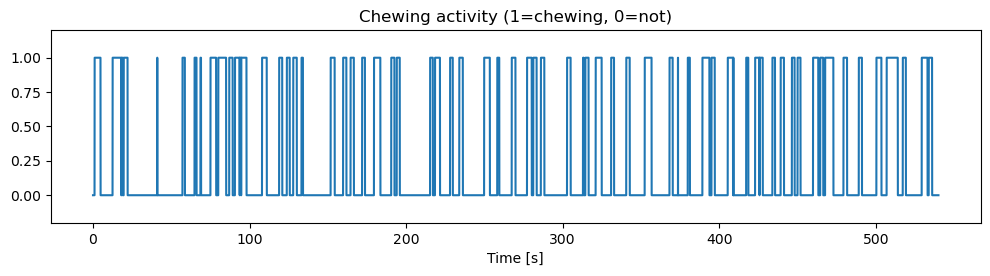

In [47]:
thr = np.nanpercentile(rms.dropna(), 70)   # праг, можеш да го смениш
chew = (rms > thr).astype(int)

plt.figure(figsize=(12,2.5))
plt.plot(time_sec, chew)
plt.ylim(-0.2, 1.2)
plt.xlabel("Time [s]")
plt.title("Chewing activity (1=chewing, 0=not)")
plt.show()


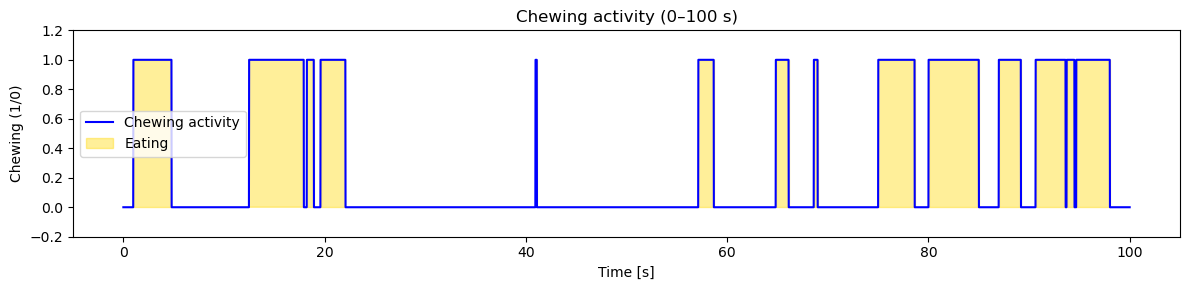

In [56]:
# zoom interval
mask = (time_sec >= 0) & (time_sec <= 100)

plt.figure(figsize=(12,3))

# binary chewing signal
plt.plot(time_sec[mask], chew[mask],
         color="blue", linewidth=1.5, label="Chewing activity")

# yellow shading where eating (chew == 1)
plt.fill_between(time_sec[mask], 0, chew[mask],
                 where=(chew[mask] == 1),
                 color="gold", alpha=0.4,
                 step="pre",
                 label="Eating")

plt.ylim(-0.2, 1.2)
plt.xlabel("Time [s]")
plt.ylabel("Chewing (1/0)")
plt.title("Chewing activity (0–100 s)")
plt.legend()
plt.tight_layout()
plt.show()


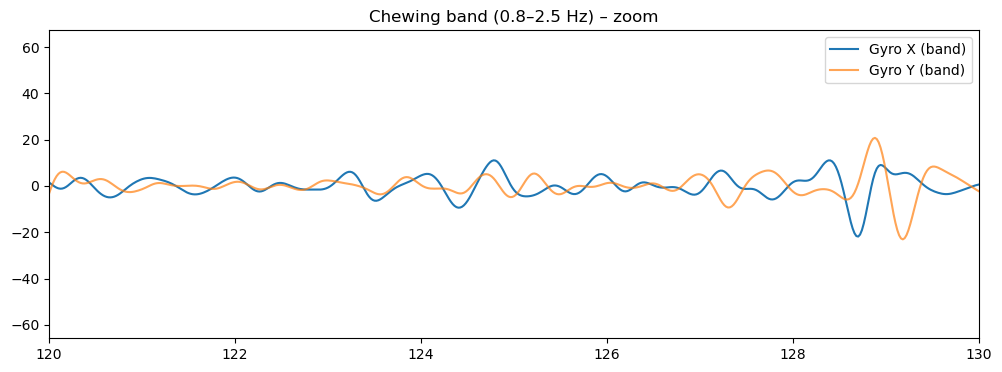

In [48]:
from scipy.signal import butter, filtfilt

low, high = 0.8, 2.5
b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")

gyro_x_f = filtfilt(b, a, df["Gyroscope X"])
gyro_y_f = filtfilt(b, a, df["Gyroscope Y"])

plt.figure(figsize=(12,4))
plt.plot(time_sec, gyro_x_f, label="Gyro X (band)")
plt.plot(time_sec, gyro_y_f, label="Gyro Y (band)", alpha=0.7)
plt.xlim(120, 130)  # пример 10 секунди
plt.legend()
plt.title("Chewing band (0.8–2.5 Hz) – zoom")
plt.show()
